# Smart City Citizen Activity — Energy & Carbon Prediction

Two supervised regression problems on the same dataset:

1. **Energy model** — predict `Home_Energy_Consumption_kWh` from citizen behaviour.
2. **Carbon model** — predict `Carbon_Footprint_kgCO2`, using the same behaviour features **plus** measured energy, since energy use is a direct physical driver of emissions.

For each target we fit **Ridge regression** (linear, penalised) and **KNN regression** (non-parametric, distance-weighted), then keep whichever has the lower RMSE.

Run cells top to bottom with `Shift+Enter`.

## 1. Setup

Run the install line **once**. `%pip` (with the percent sign) installs into the exact kernel this notebook is running on, which avoids the classic "I installed it but the import still fails" problem you get with a bare `pip`.

In [8]:
# %pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

### Load the data

Put `smart_city_citizen_activity_v2.csv` in the **same folder as this notebook**. If it lives elsewhere, give the full path instead.

In [10]:
CSV_PATH = "smart_city_citizen_activity.csv"

df = pd.read_csv(CSV_PATH)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loaded 1,000 rows x 15 columns


,Citizen_ID,Age,Gender,Mode_of_Transport,Work_Hours,Shopping_Hours,Entertainment_Hours,Home_Energy_Consumption_kWh,Charging_Station_Usage,Carbon_Footprint_kgCO2,Steps_Walked,Calories_Burned,Sleep_Hours,Social_Media_Hours,Public_Events_Hours
0,1001,56,Female,Walking,5,2,0,5.32,0,44.70,15635,975,9.2,5.8,0.5
1,1002,69,Male,Bicycle,0,2,2,2.19,0,92.39,1671,455,8.1,5.5,1.9
2,1003,46,Male,Bike,0,4,0,4.68,0,78.57,1777,324,4.7,3.8,2.8
3,1004,32,Male,Car,7,2,3,3.42,0,55.46,4022,537,4.9,3.5,0.5
4,1005,60,Male,Walking,3,3,1,2.79,0,98.95,19244,1414,6.6,2.2,0.5


## 2. Explore

Four standard checks before touching a model:

- `.head()` — do the values look like what the column names promise?
- `.info()` — dtypes and non-null counts. A numeric column showing up as `object` usually means stray text or a `?` placeholder.
- `.describe()` — ranges and spread. Look for impossible values (negative hours, age of 300).
- `.isnull().sum()` — missing data per column.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Citizen_ID                   1000 non-null   int64  
 1   Age                          1000 non-null   int64  
 2   Gender                       1000 non-null   str    
 3   Mode_of_Transport            1000 non-null   str    
 4   Work_Hours                   1000 non-null   int64  
 5   Shopping_Hours               1000 non-null   int64  
 6   Entertainment_Hours          1000 non-null   int64  
 7   Home_Energy_Consumption_kWh  1000 non-null   float64
 8   Charging_Station_Usage       1000 non-null   int64  
 9   Carbon_Footprint_kgCO2       1000 non-null   float64
 10  Steps_Walked                 1000 non-null   int64  
 11  Calories_Burned              1000 non-null   int64  
 12  Sleep_Hours                  1000 non-null   float64
 13  Social_Media_Hours           1

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Citizen_ID,1000.0,1500.50000,288.819436,1001.00,1250.7500,1500.500,1750.250,2000.00
Age,1000.0,43.81900,14.991030,18.00,31.0000,44.000,56.000,69.00
Work_Hours,1000.0,4.39700,2.870127,0.00,2.0000,4.000,7.000,9.00
Shopping_Hours,1000.0,2.02400,1.421071,0.00,1.0000,2.000,3.000,4.00
Entertainment_Hours,1000.0,1.53200,1.102811,0.00,1.0000,2.000,2.250,3.00
Home_Energy_Consumption_kWh,1000.0,5.99690,2.302009,2.00,4.0500,5.870,8.010,9.99
Charging_Station_Usage,1000.0,0.29400,0.455820,0.00,0.0000,0.000,1.000,1.00
Carbon_Footprint_kgCO2,1000.0,54.41684,26.062576,10.02,31.7175,53.665,77.865,99.93
Steps_Walked,1000.0,10514.96100,5588.931531,1011.00,5679.5000,10448.500,15377.500,19972.00
Calories_Burned,1000.0,818.61300,302.492610,171.00,581.0000,805.000,1070.000,1447.00


In [13]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values.")
print("\nDuplicate rows:", df.duplicated().sum())

No missing values.

Duplicate rows: 0


### Column roles

Rather than hard-coding names, we derive them from the dataframe — the notebook then still runs if a column is spelled slightly differently.

`ENERGY` and `CARBON` are the two targets, so they are excluded from the feature list.

In [14]:
ENERGY = "Home_Energy_Consumption_kWh"
CARBON = "Carbon_Footprint_kgCO2"

numeric_all = df.select_dtypes(include=np.number).columns.tolist()
NUMERIC_FEATURES = [c for c in numeric_all if c not in (ENERGY, CARBON)]
CATEGORICAL_FEATURES = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features   :", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)

Numeric features   : ['Citizen_ID', 'Age', 'Work_Hours', 'Shopping_Hours', 'Entertainment_Hours', 'Charging_Station_Usage', 'Steps_Walked', 'Calories_Burned', 'Sleep_Hours', 'Social_Media_Hours', 'Public_Events_Hours']
Categorical features: ['Gender', 'Mode_of_Transport']


C:\Users\Htown\AppData\Local\Temp\ipykernel_1776\4290549927.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  CATEGORICAL_FEATURES = df.select_dtypes(include=["object", "category"]).columns.tolist()


### Target distributions

Histograms tell you the *shape* of what you are predicting. A roughly symmetric bell means RMSE is a fair error measure; a long right tail means a few extreme citizens will dominate the squared error and you might consider a log transform.

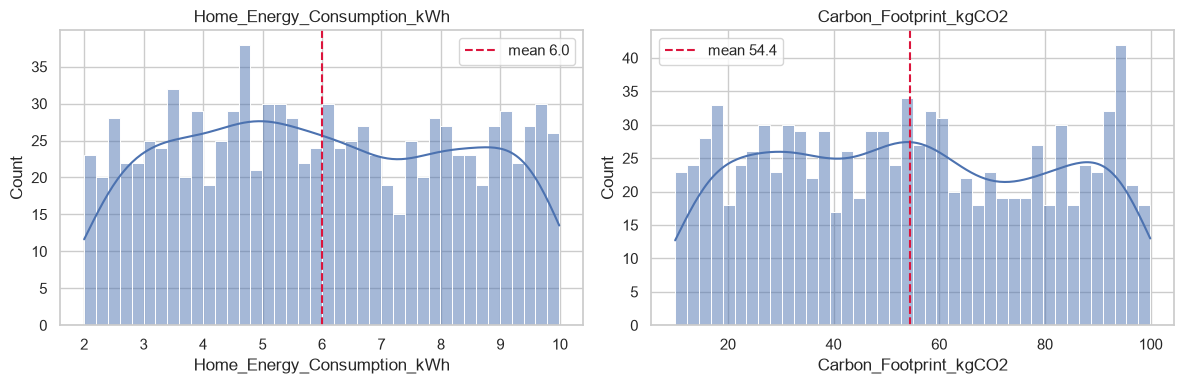

,count,mean,std,min,25%,50%,75%,max
Home_Energy_Consumption_kWh,1000.0,5.99690,2.302009,2.00,4.0500,5.870,8.010,9.99
Carbon_Footprint_kgCO2,1000.0,54.41684,26.062576,10.02,31.7175,53.665,77.865,99.93


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, [ENERGY, CARBON]):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.axvline(df[col].mean(), color="crimson", linestyle="--", label=f"mean {df[col].mean():.1f}")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

df[[ENERGY, CARBON]].describe().T

### Key chart — carbon by mode of transport

This is the headline finding: average emissions grouped by how people travel. The error bars are 95% confidence intervals, so if the bars for walking and driving do not overlap, the gap is not just noise.

C:\Users\Htown\AppData\Local\Temp\ipykernel_1776\4046703736.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x=TRANSPORT, y=CARBON, order=order,


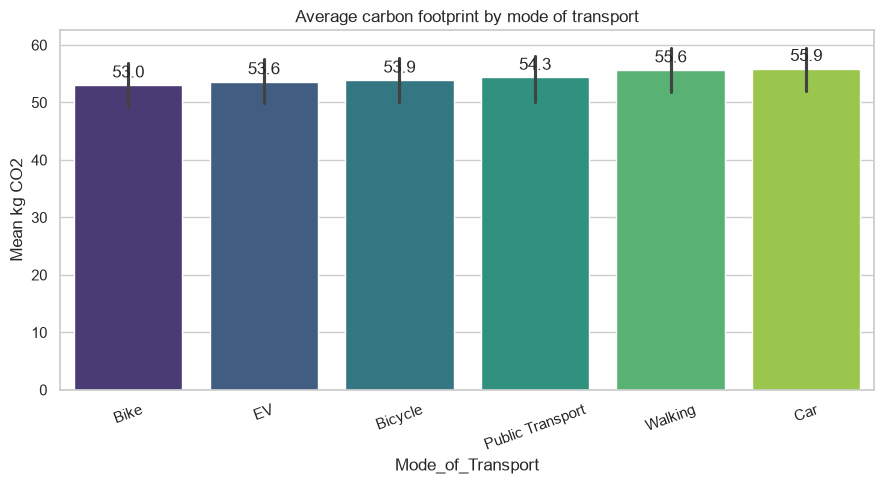

Carbon_Footprint_kgCO2              Home_Energy_Consumption_kWh             
                                    mean median count                        mean median count
Mode_of_Transport                                                                             
Bicycle                            53.86  53.08   154                        5.80   5.70   154
Bike                               53.02  53.44   176                        5.89   5.72   176
Car                                55.88  54.40   167                        5.83   5.47   167
EV                                 53.58  52.35   162                        6.18   6.06   162
Public Transport                   54.35  54.14   151                        6.03   6.08   151
Walking                            55.64  56.08   190                        6.21   6.11   190

In [16]:
TRANSPORT = "Mode_of_Transport"

if TRANSPORT in df.columns:
    order = df.groupby(TRANSPORT)[CARBON].mean().sort_values().index

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(data=df, x=TRANSPORT, y=CARBON, order=order,
                     errorbar=("ci", 95), palette="viridis")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3)
    plt.title("Average carbon footprint by mode of transport")
    plt.ylabel("Mean kg CO2")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    display(df.groupby(TRANSPORT)[[CARBON, ENERGY]]
              .agg(["mean", "median", "count"]).round(2))
else:
    print(f"Column '{TRANSPORT}' not found — check the exact spelling in df.columns")

### Correlation heatmap

Two things to read off it:

1. **Target column** — which features actually move with what you are predicting. A feature correlated at ~0.0 with the target will contribute almost nothing to a linear model.
2. **Feature-vs-feature** — anything above roughly 0.8 between two *inputs* is multicollinearity. Ridge tolerates that (it is exactly what the penalty is for), but the individual coefficients become hard to interpret.

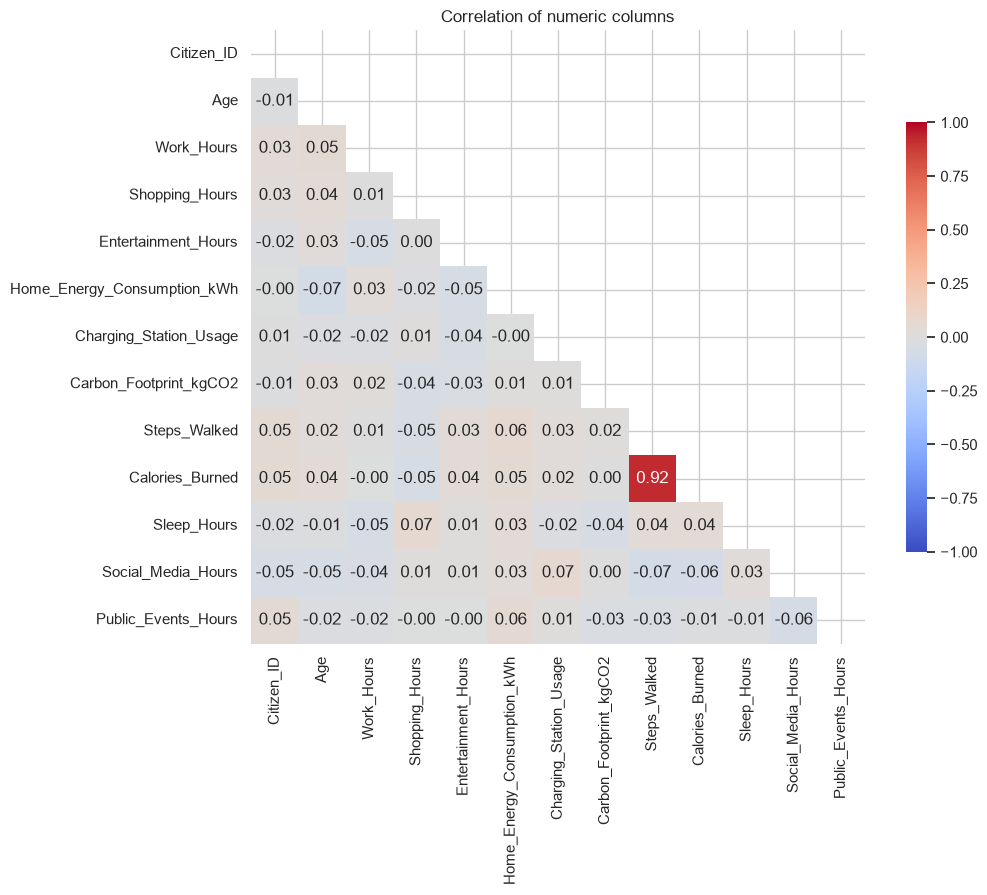

Correlation with targets, strongest first:


,Home_Energy_Consumption_kWh,Carbon_Footprint_kgCO2
Age,-0.074,0.031
Steps_Walked,0.064,0.015
Public_Events_Hours,0.061,-0.026
Calories_Burned,0.054,0.000
Entertainment_Hours,-0.050,-0.028
Sleep_Hours,0.032,-0.041
Work_Hours,0.031,0.018
Social_Media_Hours,0.027,0.002
Shopping_Hours,-0.017,-0.045
Citizen_ID,-0.001,-0.011


In [17]:
corr = df[numeric_all].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7})
plt.title("Correlation of numeric columns")
plt.tight_layout()
plt.show()

print("Correlation with targets, strongest first:")
display(corr[[ENERGY, CARBON]].drop([ENERGY, CARBON])
            .reindex(corr[ENERGY].drop([ENERGY, CARBON]).abs().sort_values(ascending=False).index)
            .round(3))

## 3. Prepare the features

**One-hot encoding.** Ridge and KNN both need numbers. `pd.get_dummies` turns `Mode_of_Transport` into one 0/1 column per category. `drop_first=True` removes one category per variable — with `Gender` reduced to a single `Gender_Male` column, "female" is encoded as 0 and absorbed into the intercept. This avoids the dummy-variable trap where columns sum to a constant.

**Standardisation.** `StandardScaler` rescales each numeric column to mean 0, standard deviation 1. It matters for both models, for different reasons:

- *Ridge* penalises the sum of squared coefficients. Without scaling, a column measured in thousands gets an artificially tiny coefficient and is barely penalised, while a column in the 0–1 range is crushed.
- *KNN* measures straight-line distance between citizens. On raw units, a variable ranging 0–5000 would completely drown out one ranging 0–8 — the "nearest" neighbours would be decided by that one column alone.

**One deviation from your step order, on purpose.** Your list scales at step 8 and splits at step 9. Fitting the scaler on the full dataset lets the test set's mean and variance leak into training, which quietly inflates your scores. Below I split first, then `fit` the scaler on train only and `transform` the test set with those same numbers. Dummies are created before the split because that is just a column reshape with no statistics involved — but I reindex the test columns to match train, in case a rare category lands only on one side.

In [18]:
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X_all = pd.get_dummies(df[FEATURE_COLS], columns=CATEGORICAL_FEATURES,
                       drop_first=True, dtype=float)
y_energy = df[ENERGY]

print("Design matrix:", X_all.shape)
print("Columns:", list(X_all.columns))
X_all.head()

Design matrix: (1000, 18)
Columns: ['Citizen_ID', 'Age', 'Work_Hours', 'Shopping_Hours', 'Entertainment_Hours', 'Charging_Station_Usage', 'Steps_Walked', 'Calories_Burned', 'Sleep_Hours', 'Social_Media_Hours', 'Public_Events_Hours', 'Gender_Male', 'Gender_Other', 'Mode_of_Transport_Bike', 'Mode_of_Transport_Car', 'Mode_of_Transport_EV', 'Mode_of_Transport_Public Transport', 'Mode_of_Transport_Walking']


,Citizen_ID,Age,Work_Hours,Shopping_Hours,Entertainment_Hours,Charging_Station_Usage,Steps_Walked,Calories_Burned,Sleep_Hours,Social_Media_Hours,Public_Events_Hours,Gender_Male,Gender_Other,Mode_of_Transport_Bike,Mode_of_Transport_Car,Mode_of_Transport_EV,Mode_of_Transport_Public Transport,Mode_of_Transport_Walking
0,1001,56,5,2,0,0,15635,975,9.2,5.8,0.5,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1002,69,0,2,2,0,1671,455,8.1,5.5,1.9,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1003,46,0,4,0,0,1777,324,4.7,3.8,2.8,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1004,32,7,2,3,0,4022,537,4.9,3.5,0.5,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1005,60,3,3,1,0,19244,1414,6.6,2.2,0.5,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [19]:
X_train, X_test, y_train_e, y_test_e = train_test_split(
    X_all, y_energy, test_size=0.2, random_state=RANDOM_STATE
)

# align columns defensively, then scale using train statistics only
X_test = X_test.reindex(columns=X_train.columns, fill_value=0.0)

scaler_e = StandardScaler().fit(X_train[NUMERIC_FEATURES])

X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[NUMERIC_FEATURES] = scaler_e.transform(X_train[NUMERIC_FEATURES])
X_test_s[NUMERIC_FEATURES]  = scaler_e.transform(X_test[NUMERIC_FEATURES])

print(f"Train {X_train_s.shape}   Test {X_test_s.shape}")
X_train_s.describe().T[["mean", "std"]].round(3).head()

Train (800, 18)   Test (200, 18)


,mean,std
Citizen_ID,-0.0,1.001
Age,-0.0,1.001
Work_Hours,-0.0,1.001
Shopping_Hours,-0.0,1.001
Entertainment_Hours,0.0,1.001


## 4. Energy model

Two candidates:

- **`Ridge(alpha=1.5)`** — ordinary least squares plus an `alpha * sum(coefficient^2)` penalty. The penalty shrinks coefficients toward zero, which trades a little bias for a useful drop in variance and keeps correlated features from producing wild offsetting weights. `alpha=1.5` is mild.
- **`KNeighborsRegressor(n_neighbors=31, weights='distance')`** — no equation is learned. To predict, it finds the 31 most similar citizens in the training set and averages their energy use, weighting closer neighbours more heavily. It captures curved and interaction effects a linear model cannot, but it degrades as the number of features grows.

Three metrics, all on the **test** set:

| Metric | Meaning | Units |
|---|---|---|
| MAE | mean absolute error — typical miss | same as target |
| RMSE | root mean squared error — punishes large misses harder | same as target |
| R² | fraction of variance explained; 0 = no better than always guessing the mean | unitless |

You select on RMSE, which is the stricter of the two error measures.

In [20]:
def evaluate(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    row = {
        "model": name,
        "MAE": mean_absolute_error(yte, pred),
        "RMSE": np.sqrt(mean_squared_error(yte, pred)),
        "R2": r2_score(yte, pred),
    }
    print(f"{name:<28} MAE {row['MAE']:8.3f}   RMSE {row['RMSE']:8.3f}   R2 {row['R2']:7.4f}")
    return row, pred

In [21]:
results = []

ridge_e = Ridge(alpha=1.5)
knn_e   = KNeighborsRegressor(n_neighbors=31, weights="distance")

r1, pred_ridge_e = evaluate("Energy - Ridge(1.5)", ridge_e, X_train_s, y_train_e, X_test_s, y_test_e)
r2_, pred_knn_e  = evaluate("Energy - KNN(31)",    knn_e,   X_train_s, y_train_e, X_test_s, y_test_e)
results += [r1, r2_]

best_energy_name, best_energy_model, pred_energy_best = (
    ("Ridge", ridge_e, pred_ridge_e) if r1["RMSE"] <= r2_["RMSE"] else ("KNN", knn_e, pred_knn_e)
)
print(f"\nLower RMSE for energy: {best_energy_name}")

Energy - Ridge(1.5)          MAE    2.005   RMSE    2.322   R2 -0.0059
Energy - KNN(31)             MAE    1.989   RMSE    2.292   R2  0.0196

Lower RMSE for energy: KNN


## 5. Carbon model

Same procedure, one change: measured energy consumption joins the inputs, because burning household energy physically produces the emissions you are predicting.

**Be aware of what this costs you.** The model now requires a *known* energy reading at prediction time. For a brand-new citizen you do not have one, so you have to run the energy model first and feed its prediction in — which means the energy model's error propagates into the carbon estimate. That chaining is done in the sample-citizen section below.

Note the scaler is re-fit here, since the feature set now has an extra column.

In [22]:
X_all_c = X_all.copy()
X_all_c[ENERGY] = df[ENERGY]
y_carbon = df[CARBON]

NUMERIC_FEATURES_C = NUMERIC_FEATURES + [ENERGY]

Xc_train, Xc_test, y_train_c, y_test_c = train_test_split(
    X_all_c, y_carbon, test_size=0.2, random_state=RANDOM_STATE
)
Xc_test = Xc_test.reindex(columns=Xc_train.columns, fill_value=0.0)

scaler_c = StandardScaler().fit(Xc_train[NUMERIC_FEATURES_C])
Xc_train_s, Xc_test_s = Xc_train.copy(), Xc_test.copy()
Xc_train_s[NUMERIC_FEATURES_C] = scaler_c.transform(Xc_train[NUMERIC_FEATURES_C])
Xc_test_s[NUMERIC_FEATURES_C]  = scaler_c.transform(Xc_test[NUMERIC_FEATURES_C])

print("Carbon design matrix:", Xc_train_s.shape)

Carbon design matrix: (800, 19)


In [23]:
ridge_c = Ridge(alpha=1.5)
knn_c   = KNeighborsRegressor(n_neighbors=31, weights="distance")

r3, pred_ridge_c = evaluate("Carbon - Ridge(1.5)", ridge_c, Xc_train_s, y_train_c, Xc_test_s, y_test_c)
r4, pred_knn_c   = evaluate("Carbon - KNN(31)",    knn_c,   Xc_train_s, y_train_c, Xc_test_s, y_test_c)
results += [r3, r4]

best_carbon_name, best_carbon_model, pred_carbon_best = (
    ("Ridge", ridge_c, pred_ridge_c) if r3["RMSE"] <= r4["RMSE"] else ("KNN", knn_c, pred_knn_c)
)
print(f"\nLower RMSE for carbon: {best_carbon_name}")

Carbon - Ridge(1.5)          MAE   23.203   RMSE   26.781   R2 -0.0101
Carbon - KNN(31)             MAE   23.031   RMSE   26.660   R2 -0.0010

Lower RMSE for carbon: KNN


## 6. Evaluate

### Comparison table

In [24]:
comparison = pd.DataFrame(results).set_index("model").round(4)
comparison["RMSE / target std"] = [
    r["RMSE"] / (y_test_e.std() if "Energy" in r["model"] else y_test_c.std())
    for r in results
]
display(comparison.round(4))

,MAE,RMSE,R2,RMSE / target std
model,,,,
Energy - Ridge(1.5),2.0051,2.3221,-0.0059,1.0004
Energy - KNN(31),1.9892,2.2924,0.0196,0.9877
Carbon - Ridge(1.5),23.2030,26.7805,-0.0101,1.0025
Carbon - KNN(31),23.0314,26.6596,-0.0010,0.9980


The extra column divides RMSE by the target's own standard deviation. Below 1.0 means the model beats simply guessing the average every time; the closer to 0, the better.

### Predicted vs actual

Points should hug the dashed diagonal. Systematic curvature away from it means the model is biased in some range — a common pattern is under-predicting the highest consumers because Ridge pulls extremes toward the middle.

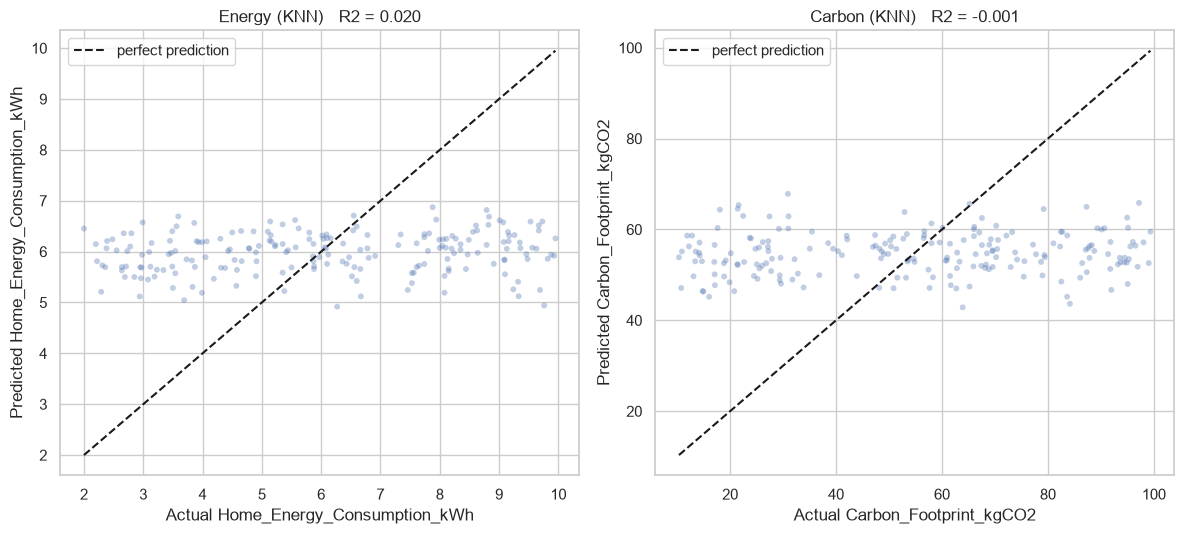

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
panels = [
    (axes[0], y_test_e, pred_energy_best, f"Energy ({best_energy_name})", ENERGY),
    (axes[1], y_test_c, pred_carbon_best, f"Carbon ({best_carbon_name})", CARBON),
]
for ax, actual, pred, title, label in panels:
    ax.scatter(actual, pred, alpha=0.35, s=18, edgecolor="none")
    lo, hi = min(actual.min(), pred.min()), max(actual.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="perfect prediction")
    ax.set_xlabel(f"Actual {label}")
    ax.set_ylabel(f"Predicted {label}")
    ax.set_title(f"{title}   R2 = {r2_score(actual, pred):.3f}")
    ax.legend()
plt.tight_layout()
plt.show()

### Residuals

Predicted-vs-actual can hide small biases. Residuals (actual − predicted) against the prediction should look like a shapeless cloud centred on zero. A funnel shape or a curve is a sign the linear form is missing something.

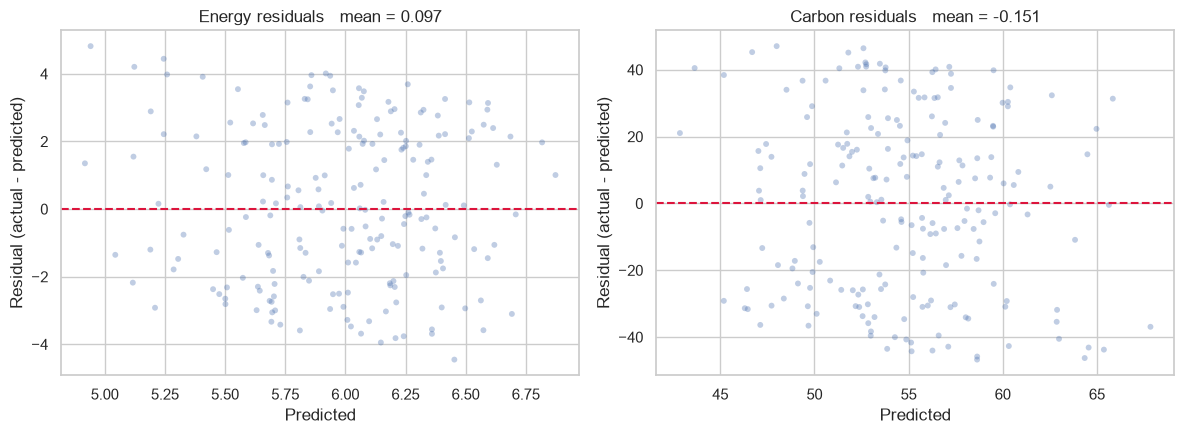

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, actual, pred, title in [
    (axes[0], y_test_e, pred_energy_best, "Energy"),
    (axes[1], y_test_c, pred_carbon_best, "Carbon"),
]:
    resid = actual - pred
    ax.scatter(pred, resid, alpha=0.35, s=18, edgecolor="none")
    ax.axhline(0, color="crimson", linestyle="--")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual (actual - predicted)")
    ax.set_title(f"{title} residuals   mean = {resid.mean():.3f}")
plt.tight_layout()
plt.show()

### Ridge coefficients

Because every numeric input was standardised, the coefficients are directly comparable: each one is the change in the target for a **one-standard-deviation** increase in that feature, holding the rest fixed. The longest bars are the behaviours that move emissions most.

Read these as **associations, not proven causes** — this is observational data, and an omitted variable (household size, for instance) could be driving both sides.

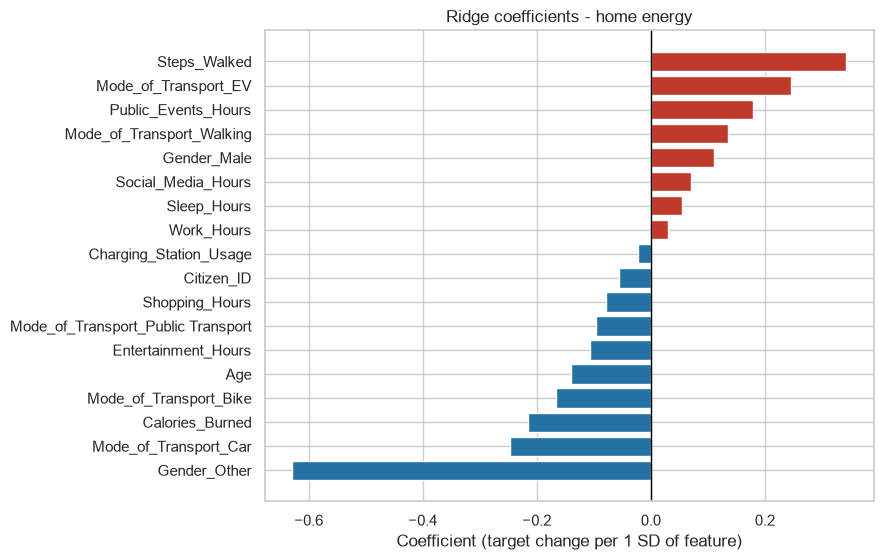

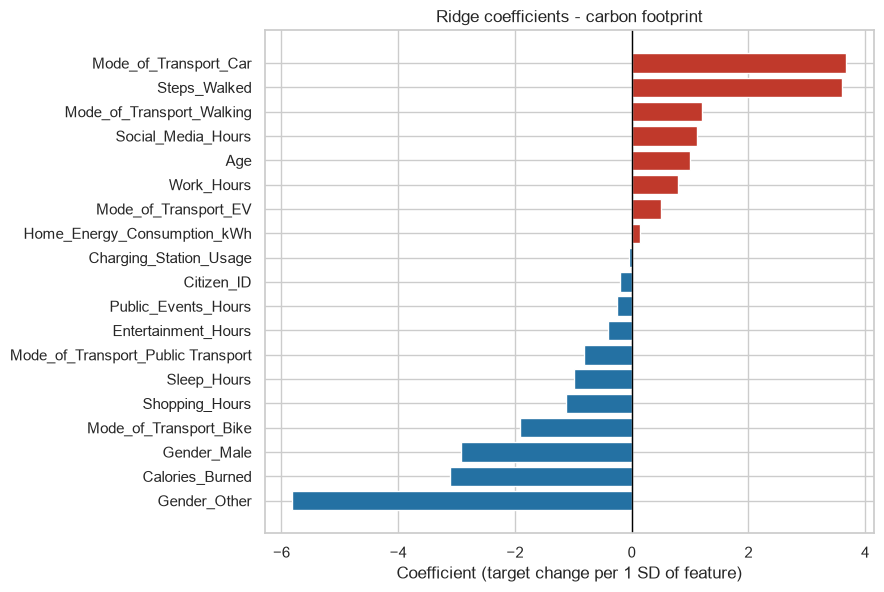

Strongest drivers of carbon:


Gender_Other                -5.8108
Mode_of_Transport_Car        3.6774
Steps_Walked                 3.6021
Calories_Burned             -3.1073
Gender_Male                 -2.9229
Mode_of_Transport_Bike      -1.9100
Mode_of_Transport_Walking    1.2125
Shopping_Hours              -1.1215
dtype: float64

In [27]:
def plot_coefficients(model, columns, title):
    coefs = pd.Series(model.coef_, index=columns).sort_values()
    plt.figure(figsize=(9, max(4, 0.32 * len(coefs))))
    colors = ["#c0392b" if v > 0 else "#2471a3" for v in coefs.values]
    plt.barh(coefs.index, coefs.values, color=colors)
    plt.axvline(0, color="black", lw=1)
    plt.xlabel("Coefficient (target change per 1 SD of feature)")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return coefs

coef_e = plot_coefficients(ridge_e, X_train_s.columns, "Ridge coefficients - home energy")
coef_c = plot_coefficients(ridge_c, Xc_train_s.columns, "Ridge coefficients - carbon footprint")

print("Strongest drivers of carbon:")
display(coef_c.reindex(coef_c.abs().sort_values(ascending=False).index).head(8).round(4))

## 7. Validate

A single 80/20 split can flatter you by luck. 5-fold cross-validation refits the model five times on different quarters of held-out data and reports all five scores. If they cluster tightly, the earlier numbers are trustworthy; if they swing widely, the model is unstable.

Scaling goes **inside a `Pipeline`** here. That is not decoration — it makes the scaler re-fit on each training fold separately, so no fold's statistics leak into its own validation set. Scaling once beforehand and then cross-validating would be exactly the leak we avoided during the split.

`cross_val_score` reports higher-is-better, so RMSE comes back negative as `neg_root_mean_squared_error`; flip the sign to read it.

In [28]:
from sklearn.base import BaseEstimator, TransformerMixin

class ColumnScaler(BaseEstimator, TransformerMixin):
    """StandardScaler applied to named columns only, leaving dummies untouched."""
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        self.scaler_ = StandardScaler().fit(X[self.columns])
        return self
    def transform(self, X):
        Xc = X.copy()
        Xc[self.columns] = self.scaler_.transform(X[self.columns])
        return Xc

In [29]:
def cv_report(label, estimator, X, y, numeric_cols):
    pipe = Pipeline([
        ("scale", ColumnScaler(numeric_cols)),
        ("model", estimator),
    ])
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    r2s   = cross_val_score(pipe, X, y, cv=kf, scoring="r2")
    rmses = -cross_val_score(pipe, X, y, cv=kf, scoring="neg_root_mean_squared_error")
    print(f"{label}")
    print(f"   R2   per fold: {np.round(r2s, 4)}   mean {r2s.mean():.4f} (+/- {r2s.std():.4f})")
    print(f"   RMSE per fold: {np.round(rmses, 3)}   mean {rmses.mean():.3f} (+/- {rmses.std():.3f})\n")
    return rmses.mean(), r2s.mean()

In [30]:
cv_report("Energy - Ridge", Ridge(alpha=1.5), X_all, y_energy, NUMERIC_FEATURES)
cv_report("Energy - KNN",   KNeighborsRegressor(n_neighbors=31, weights="distance"),
          X_all, y_energy, NUMERIC_FEATURES)
cv_report("Carbon - Ridge", Ridge(alpha=1.5), X_all_c, y_carbon, NUMERIC_FEATURES_C)
cv_report("Carbon - KNN",   KNeighborsRegressor(n_neighbors=31, weights="distance"),
          X_all_c, y_carbon, NUMERIC_FEATURES_C)

Energy - Ridge
   R2   per fold: [-0.0059 -0.0293 -0.0554 -0.0244 -0.0032]   mean -0.0236 (+/- 0.0188)
   RMSE per fold: [2.322 2.31  2.303 2.404 2.255]   mean 2.319 (+/- 0.048)

Energy - KNN
   R2   per fold: [ 0.0196 -0.0416 -0.0769 -0.0126 -0.0038]   mean -0.0231 (+/- 0.0333)
   RMSE per fold: [2.292 2.324 2.326 2.39  2.256]   mean 2.318 (+/- 0.044)

Carbon - Ridge
   R2   per fold: [-0.0101 -0.0289 -0.0175  0.0004 -0.0633]   mean -0.0239 (+/- 0.0219)
   RMSE per fold: [26.781 26.315 26.31  25.155 27.173]   mean 26.347 (+/- 0.677)

Carbon - KNN
   R2   per fold: [-0.001  -0.0091  0.008  -0.0141 -0.0378]   mean -0.0108 (+/- 0.0154)
   RMSE per fold: [26.66  26.06  25.979 25.336 26.844]   mean 26.176 (+/- 0.536)



(np.float64(26.175841763318452), np.float64(-0.010802004367033779))

## 8. Sanity check on hand-written citizens

Metrics can look fine while the model behaves absurdly. Here we invent two citizens who differ mainly in transport, and check the ordering: the car driver should come out above the walker. If it does not, something is wrong upstream — most often a column mismatch after one-hot encoding.

The helper builds a row, fills anything unspecified with the dataset **median**, and reindexes to the exact training columns. Note the chaining: the energy model predicts first, and its output feeds the carbon model.

In [31]:
def make_citizen(**overrides):
    row = {}
    for c in NUMERIC_FEATURES:
        row[c] = df[c].median()
    for c in CATEGORICAL_FEATURES:
        row[c] = df[c].mode()[0]
    row.update(overrides)
    return row

def predict_citizen(citizen):
    raw = pd.DataFrame([citizen])
    enc = pd.get_dummies(raw, columns=CATEGORICAL_FEATURES, drop_first=True, dtype=float)
    enc = enc.reindex(columns=X_train.columns, fill_value=0.0)

    enc_s = enc.copy()
    enc_s[NUMERIC_FEATURES] = scaler_e.transform(enc[NUMERIC_FEATURES])
    energy_pred = float(best_energy_model.predict(enc_s)[0])

    encc = enc.copy()
    encc[ENERGY] = energy_pred                      # chain: predicted energy feeds carbon
    encc = encc.reindex(columns=Xc_train.columns, fill_value=0.0)
    encc_s = encc.copy()
    encc_s[NUMERIC_FEATURES_C] = scaler_c.transform(encc[NUMERIC_FEATURES_C])
    carbon_pred = float(best_carbon_model.predict(encc_s)[0])

    return energy_pred, carbon_pred

print("Available transport values:", df[TRANSPORT].unique() if TRANSPORT in df else "n/a")

Available transport values: <StringArray>
['Walking', 'Bicycle', 'Bike', 'Car', 'EV', 'Public Transport']
Length: 6, dtype: str


In [32]:
# Edit the values below to match your dataset's actual categories.
samples = {
    "Car driver": make_citizen(**{TRANSPORT: "Car"}),
    "Walker":     make_citizen(**{TRANSPORT: "Walk"}),
    "Public transport": make_citizen(**{TRANSPORT: "Public Transport"}),
}

rows = []
for name, citizen in samples.items():
    try:
        e, c = predict_citizen(citizen)
        rows.append({"citizen": name, "pred_energy_kWh": round(e, 2), "pred_carbon_kgCO2": round(c, 2)})
    except Exception as err:
        print(f"{name}: {err}")

sample_df = pd.DataFrame(rows).set_index("citizen")
display(sample_df)

if len(sample_df) >= 2:
    top, bottom = sample_df["pred_carbon_kgCO2"].idxmax(), sample_df["pred_carbon_kgCO2"].idxmin()
    print(f"Highest predicted carbon: {top}   |   Lowest: {bottom}")
    print("Ordering is physically sensible." if top != bottom else "Check the transport labels above.")

,pred_energy_kWh,pred_carbon_kgCO2
citizen,,
Car driver,6.53,59.35
Walker,6.53,59.35
Public transport,6.53,59.35


Highest predicted carbon: Car driver   |   Lowest: Car driver
Check the transport labels above.


## 9. Save the models

`joblib` serialises the fitted estimator to disk so a backend can load it without retraining.

**Save the scalers too.** A model without its scaler is useless — new inputs must be transformed with the *same* means and standard deviations seen during training, and those live inside the scaler object. Save the column order for the same reason: one-hot columns must line up exactly.

In [33]:
joblib.dump(best_energy_model, "energy_model.pkl")
joblib.dump(best_carbon_model, "carbon_model.pkl")

joblib.dump({
    "scaler_energy": scaler_e,
    "scaler_carbon": scaler_c,
    "numeric_features": NUMERIC_FEATURES,
    "numeric_features_carbon": NUMERIC_FEATURES_C,
    "energy_columns": list(X_train.columns),
    "carbon_columns": list(Xc_train.columns),
    "best_energy_algo": best_energy_name,
    "best_carbon_algo": best_carbon_name,
}, "preprocessing.pkl")

print("Saved: energy_model.pkl, carbon_model.pkl, preprocessing.pkl")

# reload check
check = joblib.load("energy_model.pkl")
print("Reload OK, matches:", np.allclose(check.predict(X_test_s), best_energy_model.predict(X_test_s)))

Saved: energy_model.pkl, carbon_model.pkl, preprocessing.pkl
Reload OK, matches: True
